# GloGEM vs GloGEMflow: regional comparisons

Total volume, relative volume and area timeseries comparing the Δh parameterisation against the
SIA flowline model, across the regions run for the GlacierMIP4 (GMIP4) submission.

**CentralEurope (RGI region 11)** gets the full treatment below: the original CMIP6 ensemble
(13 GCMs, RGI6 vs RGI7), the GMIP4 ensemble (8 GCMs), and a driver-glacier deep dive into what's
behind the flow/Δh divergence. **Iceland and New Zealand** (added once their GMIP4 runs
completed) get the GMIP4 comparison only, at the bottom of this notebook — both were run RGI7
only, with no CMIP6 or driver-glacier equivalent (yet).

| Model | RGI version | Geometry | Style |
|-------|-------------|----------|-------|
| **GloGEMflow** | RGI7 | SIA flowline dynamics (Zekollari et al. 2019) | thick solid |
| **GloGEMflow** | RGI6 | SIA flowline dynamics (Zekollari et al. 2019) | thin solid |
| **GloGEM** | RGI7 | Δh parameterisation (Huss et al. 2010) | thick dashed |
| **GloGEM** | RGI6 | Δh parameterisation (Huss et al. 2010) | thin dashed |

## CentralEurope — CMIP6 ensemble

GCM ensemble: all 13 available CMIP6 models (mean). SSPs: 1-2.6, 2-4.5, 5-8.5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

rcParams['font.family']       = 'sans-serif'
rcParams['font.sans-serif']   = ['Liberation Sans', 'Arial', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False
rcParams['axes.spines.top']    = False
rcParams['axes.spines.right']  = False

In [2]:
# ── Run directories ───────────────────────────────────────────────────────────
_BASE = '/scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development'
_SUB  = 'monthly/CentralEurope/files/files_original'

RUNS = {
    'dh_rgi7':   f'{_BASE}/alps_dhdt_rgi7',
    'dh_rgi6':   f'{_BASE}/alps_dhdt_rgi6',
    'flow_rgi7': f'{_BASE}/alps_flow_rgi7',
    'flow_rgi6': f'{_BASE}/alps_flow_rgi6',
}

# ── Batch configuration (all four runs use 24 batches) ───────────────────────
N_BATCHES    = 24
BATCH_PREFIX = 'alps_batch'

# ── GCMs — all 13 available CMIP6 models ────────────────────────────────────
ALL_GCMS = [
    'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM',
    'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4',
    'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM',
]

# ── SSPs and styling ──────────────────────────────────────────────────────────
SSPS       = ['ssp126', 'ssp245', 'ssp585']
SSP_LABELS = {'ssp126': 'SSP1-2.6', 'ssp245': 'SSP2-4.5', 'ssp585': 'SSP5-8.5'}
SSP_COLORS = {'ssp126': '#5492CD', 'ssp245': '#F6B334', 'ssp585': '#DC1C13'}

# ── Plot style per run: solid = flow, dashed = Δh; thick = RGI7, thin = RGI6 ─
RUN_STYLE = {
    'flow_rgi7': dict(ls='-',  lw=2.0, label='GloGEMflow  RGI7'),
    'flow_rgi6': dict(ls='-',  lw=1.0, label='GloGEMflow  RGI6'),
    'dh_rgi7':   dict(ls='--', lw=2.0, label='Δh param.   RGI7'),
    'dh_rgi6':   dict(ls='--', lw=1.0, label='Δh param.   RGI6'),
}

# ── Time axis (GloGEM output: 1940–2099, 160 years) ──────────────────────────
TRAN0   = 1940
N_YEARS = 160          # 1940–2099 inclusive
years   = np.arange(TRAN0, TRAN0 + N_YEARS)
I_2020  = 2020 - TRAN0   # index 80
I_LAST  = N_YEARS - 1    # index 159 = year 2099

# ── Inventory / survey date (nominal RGI outline date for Central Europe) ────
INVENTORY_YEAR = 2003

In [3]:
from concurrent.futures import ThreadPoolExecutor

def _read_dat(path, row_max=None):
    """Read one .dat file; return column-summed array or None if missing/corrupt.

    Uses str.split()+float() (fast, C-level) rather than a regex scan — with
    ~7500 files across all runs/GCMs/SSPs/batches, the regex approach was
    CPU-bound and serialized by the GIL despite ThreadPoolExecutor, making
    the whole notebook take 6+ minutes to load. Malformed tokens ('*' from
    IDL overflow) raise ValueError and are treated as 0. IDL's '-NaN'/'NaN'
    tokens (melted glacier) do NOT raise ValueError -- Python's float()
    parses them silently into a real nan -- so they're caught explicitly via
    np.isnan() and zeroed too, otherwise `total += vals` propagates nan into
    every subsequent year for the whole regional sum, not just that glacier.
    A melted-out glacier contributes zero volume from then on, which is the
    physically correct treatment, not a nan poisoning the entire aggregate.
    Handled per-column-position rather than stripped from the line first --
    stripping first can silently shift later columns if a malformed token
    isn't at the row end.
    """
    try:
        with open(path) as fh:
            header = fh.readline()
            ncols  = len(header.split()) - 1
            if ncols <= 0:
                return None
            total = np.zeros(ncols)
            for line in fh:
                parts = line.split()
                if len(parts) < 2:
                    continue
                vals = np.zeros(ncols)
                row_peak = 0.0
                for j, tok in enumerate(parts[1:ncols + 1]):  # parts[0] = glacier ID
                    try:
                        v = float(tok)
                    except ValueError:
                        v = 0.0   # '*' (overflow)
                    if np.isnan(v):
                        v = 0.0   # '-NaN'/'NaN' (melted glacier) -- zero, don't poison the sum
                    vals[j] = v
                    if v > row_peak:
                        row_peak = v
                if row_max is not None and row_peak > row_max:
                    continue   # skip blown-up glacier row
                total += vals
    except (FileNotFoundError, OSError, ValueError):
        return None
    return total


def _sum_gcm_batches(args):
    """Sum all batch files for one (rundir, var, ssp, gcm) — run in thread."""
    rundir, var, ssp, gcm, row_max, sub_path, file_prefix, batch_prefix, n_batches, n_years = args
    total, found = None, 0
    for i in range(1, n_batches + 1):
        path = (f'{rundir}/{sub_path}/{gcm}/{ssp}/'
                f'{file_prefix}_{var}_r1_{batch_prefix}{i:02d}.dat')
        arr = _read_dat(path, row_max=row_max)
        if arr is not None:
            total = arr if total is None else total + arr
            found += 1
    # Truncate to a common length before returning. GMIP4 runs auto-extend
    # tran[1] to 2300 for some GCM/SSP combinations but not others within the
    # SAME 8-model ensemble (procedures/initialise/check_tran.pro, merged in
    # from main on 2026-08-03) -- so raw files are no longer uniform length,
    # and np.mean() over ragged arrays raises "could not be broadcast
    # together". N_YEARS (160, 1940-2099) is a safe common prefix: every
    # GMIP4 GCM/SSP combination runs at least through 2100, and non-GMIP4
    # (CMIP6) files are already exactly N_YEARS long, so this is a no-op
    # for them.
    # Pad (not just truncate) to exactly n_years: the overshoot scenario
    # (ssp534-over) has 3/4 GCMs running to 2300 and MIROC6 stopping at 2100
    # within the SAME ensemble -- shorter series are NaN-padded rather than
    # dropped, so load_mean's nanmean below still uses every GCM for the
    # years it actually covers instead of truncating the whole ensemble
    # down to the shortest member's length.
    if total is not None and len(total) != n_years:
        if len(total) > n_years:
            total = total[:n_years]
        else:
            padded = np.full(n_years, np.nan)
            padded[:len(total)] = total
            total = padded
    return total, found, gcm


def load_mean(rundir, var, ssp, row_max=None, gcms=None,
              sub_path=_SUB, file_prefix='centraleurope',
              batch_prefix=BATCH_PREFIX, n_batches=N_BATCHES, n_years=N_YEARS):
    """GCM-ensemble mean across all batches; parallelises GCM reads via threads.

    `gcms` defaults to ALL_GCMS (the 13-model CMIP6 ensemble) but can be
    overridden — e.g. GMIP4_GCMS for the 8-model GMIP4 ensemble, which uses
    a different GCM roster entirely. `sub_path`/`file_prefix`/`batch_prefix`/
    `n_batches` default to the CentralEurope/Alps layout but can be
    overridden per region (see ICELAND / NEW_ZEALAND specs further down) --
    different regions use different dir_region path components, filename
    prefixes and batch counts.
    """
    if gcms is None:
        gcms = ALL_GCMS
    args = [(rundir, var, ssp, gcm, row_max, sub_path, file_prefix, batch_prefix, n_batches, n_years)
            for gcm in gcms]
    with ThreadPoolExecutor(max_workers=len(gcms)) as ex:
        results = list(ex.map(_sum_gcm_batches, args))
    gcm_totals = []
    for total, found, gcm in results:
        if total is None:
            print(f'[missing all] {gcm}/{ssp}/{var}')
        elif found < n_batches:
            print(f'[partial {found}/{n_batches}] {gcm}/{ssp}/{var}')
        if total is not None:
            gcm_totals.append(total)
    return np.nanmean(gcm_totals, axis=0) if gcm_totals else None  # nanmean: see padding note above

In [4]:
def _load_one(args):
    tag, rundir, var, ssp = args
    row_max = 50. if var == 'Volume' else 500.
    return tag, var, ssp, load_mean(rundir, var, ssp, row_max=row_max)

tasks = [
    (tag, d, var, s)
    for tag, d in RUNS.items()
    for var in ('Volume', 'Area')
    for s in SSPS
]

vol  = {tag: {} for tag in RUNS}
area = {tag: {} for tag in RUNS}

with ThreadPoolExecutor(max_workers=6) as ex:
    for tag, var, ssp, result in ex.map(_load_one, tasks):
        (vol if var == 'Volume' else area)[tag][ssp] = result

# Sanity check
for tag in ['dh_rgi7', 'dh_rgi6', 'flow_rgi7', 'flow_rgi6']:
    for s in SSPS:
        v = vol[tag][s]
        if v is not None:
            print(f'{tag:<12}  {SSP_LABELS[s]}  '
                  f'vol_2020={v[I_2020]:.1f} km³   vol_2099={v[I_LAST]:.1f} km³')

dh_rgi7       SSP1-2.6  vol_2020=82.5 km³   vol_2099=24.0 km³
dh_rgi7       SSP2-4.5  vol_2020=82.5 km³   vol_2099=11.3 km³
dh_rgi7       SSP5-8.5  vol_2020=82.5 km³   vol_2099=2.8 km³
dh_rgi6       SSP1-2.6  vol_2020=100.2 km³   vol_2099=25.8 km³
dh_rgi6       SSP2-4.5  vol_2020=100.2 km³   vol_2099=11.7 km³
dh_rgi6       SSP5-8.5  vol_2020=100.2 km³   vol_2099=2.6 km³
flow_rgi7     SSP1-2.6  vol_2020=82.2 km³   vol_2099=33.2 km³
flow_rgi7     SSP2-4.5  vol_2020=82.2 km³   vol_2099=18.1 km³
flow_rgi7     SSP5-8.5  vol_2020=82.2 km³   vol_2099=6.1 km³
flow_rgi6     SSP1-2.6  vol_2020=96.9 km³   vol_2099=30.3 km³
flow_rgi6     SSP2-4.5  vol_2020=96.9 km³   vol_2099=14.3 km³
flow_rgi6     SSP5-8.5  vol_2020=96.9 km³   vol_2099=2.7 km³


In [5]:
# ── Flow-model run health: SIA activations vs. blow-ups ──────────────────────
# Reads directly from the IDL batch logs (not the .dat output), since blow-up
# events are a run-time/numerical-stability diagnostic, not a model output.
# A "blow-up" is a glacier whose SIA integration hit max(thick_dx)>5000m or a
# non-finite state on some year; it then permanently falls back to the Δh
# parameterisation for the rest of that run (glogemflow_coupled.pro STEP 3).
import glob as _glob
import os as _os

LOG_DIR = '/home/jabeer/projects/glogemflow_development/GloGEM/logs'

FLOW_LOG_PREFIXES = {
    'flow_rgi7': 'flow_rgi7_fwd',
    'flow_rgi6': 'flow_rgi6_fwd',
}

def _latest_log(prefix, batch, n_batches=N_BATCHES):
    pattern = f'{LOG_DIR}/{prefix}_batch{batch:02d}_*.log'
    matches = _glob.glob(pattern)
    return max(matches, key=_os.path.getmtime) if matches else None

def flow_run_health(prefix, n_batches=N_BATCHES):
    """Count SIA activations and blow-ups per batch's latest log, split by SSP."""
    activations, blowups = 0, 0
    per_ssp = {}   # ssp -> [activations, blowups]
    for b in range(1, n_batches + 1):
        path = _latest_log(prefix, b, n_batches)
        if path is None:
            continue
        ssp = None
        with open(path, errors='ignore') as fh:
            for line in fh:
                if 'calculated with GCM' in line:
                    ssp = line.rsplit('/', 1)[-1].strip()
                elif 'GloGEMflow coupled: initialised at year' in line:
                    activations += 1
                    if ssp:
                        per_ssp.setdefault(ssp, [0, 0])[0] += 1
                elif 'GloGEMflow blow-up' in line:
                    blowups += 1
                    if ssp:
                        per_ssp.setdefault(ssp, [0, 0])[1] += 1
    return activations, blowups, per_ssp

print('-- Flow-model run health (SIA activations = glacier x GCM x SSP instances) --')
for tag, prefix in FLOW_LOG_PREFIXES.items():
    act, blow, per_ssp = flow_run_health(prefix)
    ok = act - blow
    rate = blow / act * 100 if act else float('nan')
    print(f'\n{tag}:  {act} activations  |  {ok} completed the full SIA run ({100 - rate:.2f}%)  |  '
          f'{blow} blow-ups ({rate:.2f}%, fell back to Δh)')
    for ssp in sorted(per_ssp, key=lambda s: SSPS.index(s) if s in SSPS else 99):
        a, bl = per_ssp[ssp]
        r = bl / a * 100 if a else float('nan')
        label = SSP_LABELS.get(ssp, ssp)
        print(f'    {label:<10} activations={a:<7} blow-ups={bl:<5} rate={r:.2f}%')

-- Flow-model run health (SIA activations = glacier x GCM x SSP instances) --

flow_rgi7:  0 activations  |  0 completed the full SIA run (nan%)  |  0 blow-ups (nan%, fell back to Δh)

flow_rgi6:  0 activations  |  0 completed the full SIA run (nan%)  |  0 blow-ups (nan%, fell back to Δh)


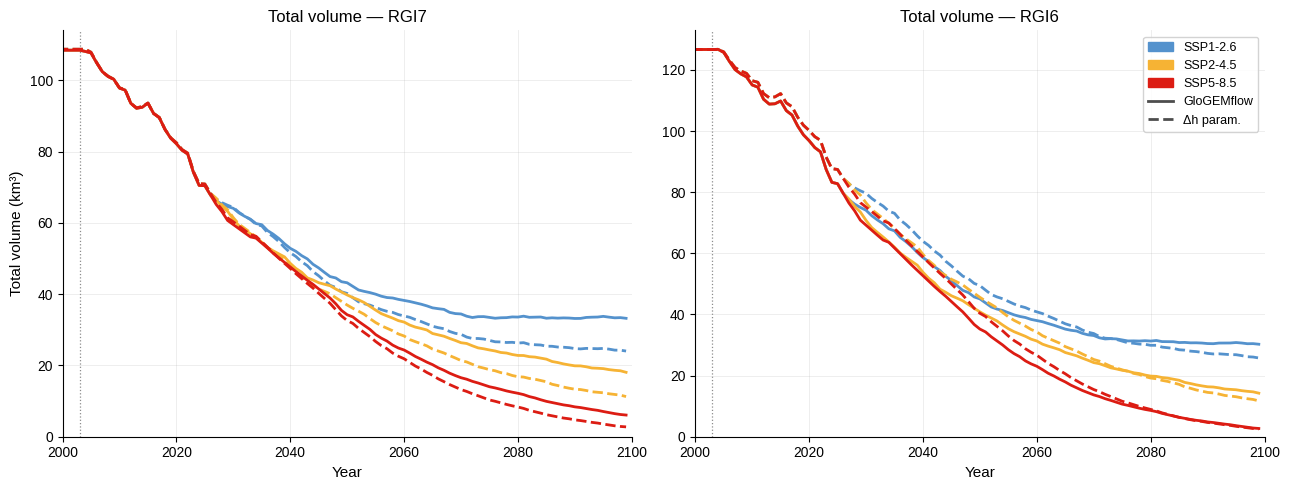

In [6]:
# ── Figure 1: Total volume — RGI7 (left) vs RGI6 (right) ────────────────────
PANELS = [
    ('RGI7', 'flow_rgi7', 'dh_rgi7'),
    ('RGI6', 'flow_rgi6', 'dh_rgi6'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (rgi_label, flow_tag, dh_tag) in zip(axes, PANELS):
    for ssp in SSPS:
        c = SSP_COLORS[ssp]
        for tag, ls in [(flow_tag, '-'), (dh_tag, '--')]:
            v = vol[tag][ssp]
            if v is not None:
                ax.plot(years, v, color=c, ls=ls, lw=2.0)
    ax.axvline(INVENTORY_YEAR, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(f'Total volume — {rgi_label}', fontsize=12)
    ax.grid(True, alpha=0.25, lw=0.6)

axes[0].set_ylabel('Total volume (km³)', fontsize=11)

legend_ssp = [Patch(color=SSP_COLORS[s], label=SSP_LABELS[s]) for s in SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=2.0, label='GloGEMflow'),
    Line2D([0], [0], color='0.3', ls='--', lw=2.0, label='Δh param.'),
]
axes[1].legend(handles=legend_ssp + legend_mdl, fontsize=9,
               loc='upper right', framealpha=0.85)

fig.tight_layout()
plt.show()

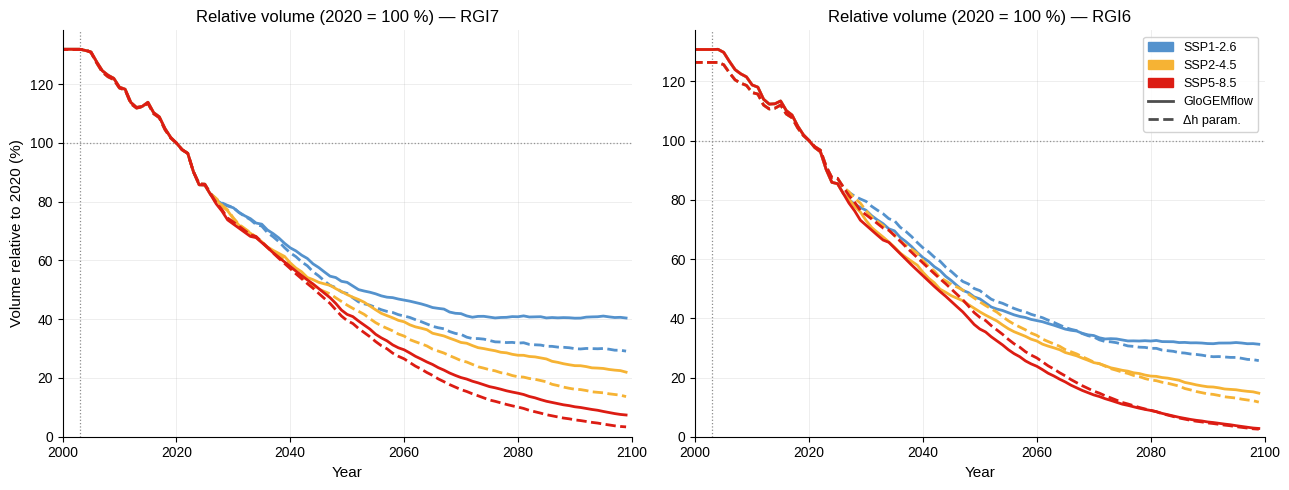

In [7]:
# ── Figure 2: Relative volume (2020 = 100 %) — RGI7 (left) vs RGI6 (right) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (rgi_label, flow_tag, dh_tag) in zip(axes, PANELS):
    for ssp in SSPS:
        c = SSP_COLORS[ssp]
        for tag, ls in [(flow_tag, '-'), (dh_tag, '--')]:
            v = vol[tag][ssp]
            if v is not None and v[I_2020] > 0:
                ax.plot(years, v / v[I_2020] * 100, color=c, ls=ls, lw=2.0)
    ax.axhline(100, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.axvline(INVENTORY_YEAR, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(f'Relative volume (2020 = 100 %) — {rgi_label}', fontsize=12)
    ax.grid(True, alpha=0.25, lw=0.6)

axes[0].set_ylabel('Volume relative to 2020 (%)', fontsize=11)

legend_ssp = [Patch(color=SSP_COLORS[s], label=SSP_LABELS[s]) for s in SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=2.0, label='GloGEMflow'),
    Line2D([0], [0], color='0.3', ls='--', lw=2.0, label='Δh param.'),
]
axes[1].legend(handles=legend_ssp + legend_mdl, fontsize=9,
               loc='upper right', framealpha=0.85)

fig.tight_layout()
plt.show()

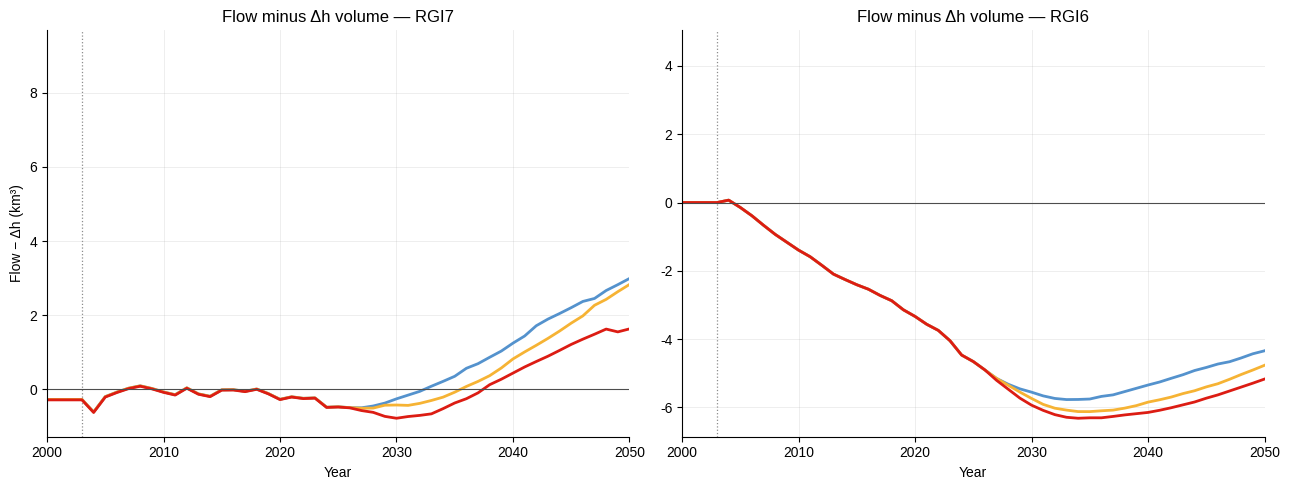

RGI7 SSP1-2.6: |flow-dh| first exceeds 1 km3 at year 2039 (diff=1.03)
RGI7 SSP2-4.5: |flow-dh| first exceeds 1 km3 at year 2041 (diff=1.01)
RGI7 SSP5-8.5: |flow-dh| first exceeds 1 km3 at year 2044 (diff=1.05)
RGI6 SSP1-2.6: |flow-dh| first exceeds 1 km3 at year 2009 (diff=1.16)
RGI6 SSP2-4.5: |flow-dh| first exceeds 1 km3 at year 2009 (diff=1.16)
RGI6 SSP5-8.5: |flow-dh| first exceeds 1 km3 at year 2009 (diff=1.16)


In [8]:
# ── Figure 2b: Flow minus Δh volume, zoomed on the early divergence period ──
# When does the flow/Δh gap actually start opening up, and how fast?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (rgi_label, flow_tag, dh_tag) in zip(axes, PANELS):
    for ssp in SSPS:
        c = SSP_COLORS[ssp]
        vf, vd = vol[flow_tag][ssp], vol[dh_tag][ssp]
        if vf is not None and vd is not None:
            ax.plot(years, vf - vd, color=c, lw=2.0)
    ax.axhline(0, color='0.3', lw=0.8)
    ax.axvline(INVENTORY_YEAR, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.set_xlim(2000, 2050)
    ax.set_xlabel('Year')
    ax.set_title(f'Flow minus Δh volume — {rgi_label}')
    ax.grid(True, alpha=0.25, lw=0.6)
axes[0].set_ylabel('Flow − Δh (km³)')
fig.tight_layout()
plt.show()

# Print the exact year each region/SSP's |flow-dh| first exceeds 1 km3
for tag_pair, label in [(('flow_rgi7', 'dh_rgi7'), 'RGI7'), (('flow_rgi6', 'dh_rgi6'), 'RGI6')]:
    ftag, dtag = tag_pair
    for ssp in SSPS:
        vf, vd = vol[ftag][ssp], vol[dtag][ssp]
        if vf is None or vd is None:
            continue
        diff = np.abs(vf - vd)
        idx = np.argmax(diff > 1.0)
        print(f'{label} {SSP_LABELS[ssp]}: |flow-dh| first exceeds 1 km3 at year {years[idx]} (diff={diff[idx]:.2f})')

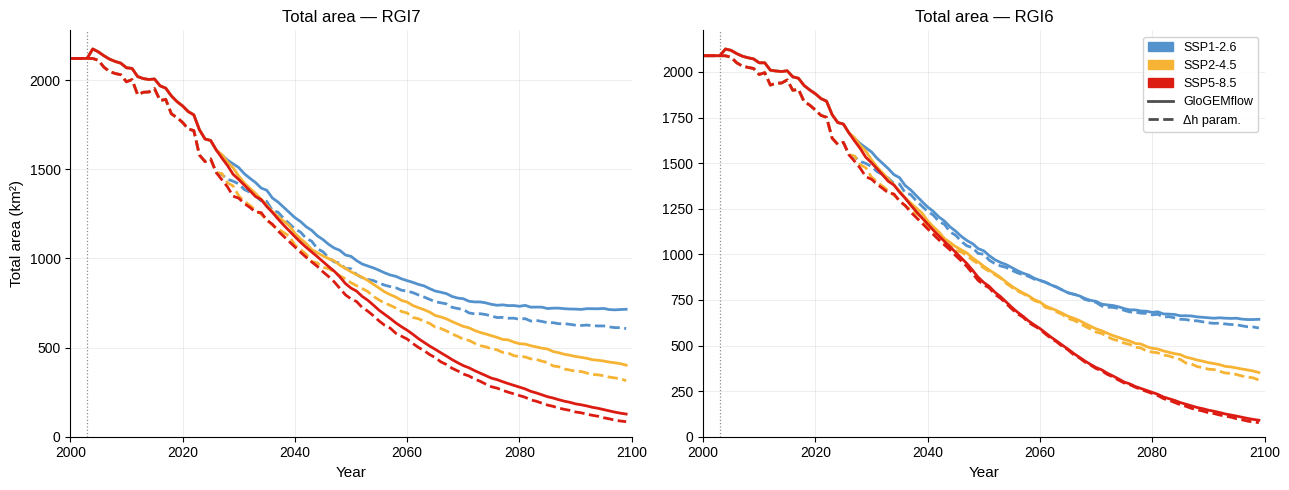

In [9]:
# ── Figure 3: Total area — RGI7 (left) vs RGI6 (right) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (rgi_label, flow_tag, dh_tag) in zip(axes, PANELS):
    for ssp in SSPS:
        c = SSP_COLORS[ssp]
        for tag, ls in [(flow_tag, '-'), (dh_tag, '--')]:
            a = area[tag][ssp]
            if a is not None:
                ax.plot(years, a, color=c, ls=ls, lw=2.0)
    ax.axvline(INVENTORY_YEAR, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(f'Total area — {rgi_label}', fontsize=12)
    ax.grid(True, alpha=0.25, lw=0.6)

axes[0].set_ylabel('Total area (km²)', fontsize=11)

legend_ssp = [Patch(color=SSP_COLORS[s], label=SSP_LABELS[s]) for s in SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=2.0, label='GloGEMflow'),
    Line2D([0], [0], color='0.3', ls='--', lw=2.0, label='Δh param.'),
]
axes[1].legend(handles=legend_ssp + legend_mdl, fontsize=9,
               loc='upper right', framealpha=0.85)

fig.tight_layout()
plt.show()

In [10]:
# ── Summary table ─────────────────────────────────────────────────────────────
TAGS    = ['dh_rgi7', 'dh_rgi6', 'flow_rgi7', 'flow_rgi6']
CLABELS = ['Δh-RGI7', 'Δh-RGI6', 'Flow-RGI7', 'Flow-RGI6']
W = 10

hdr = f"{'SSP':<12}" + "".join(f"  {c:>{W}}" for c in CLABELS)
sep = '-' * len(hdr)

def _v(tag, ssp, idx):
    v = vol[tag][ssp]
    return v[idx] if v is not None else float('nan')

print('-- Volume 2020 (km³) --')
print(hdr);  print(sep)
for ssp in SSPS:
    print(f'{SSP_LABELS[ssp]:<12}' + ''.join(f'  {_v(t,ssp,I_2020):>{W}.1f}' for t in TAGS))

print()
print('-- Volume 2099 (km³) --')
print(hdr);  print(sep)
for ssp in SSPS:
    print(f'{SSP_LABELS[ssp]:<12}' + ''.join(f'  {_v(t,ssp,I_LAST):>{W}.1f}' for t in TAGS))

print()
print('-- Volume loss 2020→2099 (%) --')
print(hdr);  print(sep)
for ssp in SSPS:
    row = f'{SSP_LABELS[ssp]:<12}'
    for tag in TAGS:
        v20, v99 = _v(tag, ssp, I_2020), _v(tag, ssp, I_LAST)
        loss = (1 - v99 / v20) * 100 if v20 > 0 else float('nan')
        row += f'  {loss:>{W}.1f}%'
    print(row)

print('\nΔh = Δh parameterisation.  Flow = GloGEMflow.  All volumes in km³.')

-- Volume 2020 (km³) --
SSP              Δh-RGI7     Δh-RGI6   Flow-RGI7   Flow-RGI6
------------------------------------------------------------
SSP1-2.6            82.5       100.2        82.2        96.9
SSP2-4.5            82.5       100.2        82.2        96.9
SSP5-8.5            82.5       100.2        82.2        96.9

-- Volume 2099 (km³) --
SSP              Δh-RGI7     Δh-RGI6   Flow-RGI7   Flow-RGI6
------------------------------------------------------------
SSP1-2.6            24.0        25.8        33.2        30.3
SSP2-4.5            11.3        11.7        18.1        14.3
SSP5-8.5             2.8         2.6         6.1         2.7

-- Volume loss 2020→2099 (%) --
SSP              Δh-RGI7     Δh-RGI6   Flow-RGI7   Flow-RGI6
------------------------------------------------------------
SSP1-2.6            70.9%        74.3%        59.6%        68.8%
SSP2-4.5            86.3%        88.3%        78.0%        85.3%
SSP5-8.5            96.7%        97.4%        92.6%     

## CentralEurope — GMIP4 ensemble

Same comparison (RGI6 vs RGI7, Δh parameterisation vs GloGEMflow dynamics), but using the
Glacier Model Intercomparison Project 4 (GMIP4) protocol ensemble instead of the full CMIP6
set above — this is the ensemble/scenario combination our group needs for the GMIP4 submission.

GCM ensemble: 8 GMIP4 models (mean). SSPs: 1-2.6, 3-7.0, 5-8.5 (GMIP4's protocol scenarios).

Runs are launched via `scripts/run_gmip4_all.sh` — separate output directories
(`alps_{flow,dhdt}_rgi{6,7}_gmip4`) from the CMIP6 runs, so re-running this section requires
that script to have completed (or at least produced partial output for the batches it's reached).

In [11]:
# ── GMIP4 run directories, GCMs, SSPs ─────────────────────────────────────────
RUNS_GMIP4 = {
    'dh_rgi7':   f'{_BASE}/alps_dhdt_rgi7_gmip4',
    'dh_rgi6':   f'{_BASE}/alps_dhdt_rgi6_gmip4',
    'flow_rgi7': f'{_BASE}/alps_flow_rgi7_gmip4',
    'flow_rgi6': f'{_BASE}/alps_flow_rgi6_gmip4',
}

# GMIP4 protocol ensemble — 8 models (settings.pro 'GMIP4' case), all confirmed
# to have complete ssp126/ssp370/ssp585 monthly data for CentralEurope.
GMIP4_GCMS = [
    'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CESM2-WACCM', 'IPSL-CM6A-LR',
    'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM',
]

GMIP4_SSPS       = ['ssp126', 'ssp370', 'ssp585']
GMIP4_SSP_LABELS = {'ssp126': 'SSP1-2.6', 'ssp370': 'SSP3-7.0', 'ssp585': 'SSP5-8.5'}
GMIP4_SSP_COLORS = {'ssp126': '#5492CD', 'ssp370': '#8E5AA8', 'ssp585': '#DC1C13'}

In [12]:
# ── Load GMIP4 volume + area (same machinery as the CMIP6 load above, but with
#    GMIP4_GCMS / GMIP4_SSPS / RUNS_GMIP4) ────────────────────────────────────
def _load_one_gmip4(args):
    tag, rundir, var, ssp = args
    row_max = 50. if var == 'Volume' else 500.
    return tag, var, ssp, load_mean(rundir, var, ssp, row_max=row_max, gcms=GMIP4_GCMS)

tasks_gmip4 = [
    (tag, d, var, s)
    for tag, d in RUNS_GMIP4.items()
    for var in ('Volume', 'Area')
    for s in GMIP4_SSPS
]

vol_gmip4  = {tag: {} for tag in RUNS_GMIP4}
area_gmip4 = {tag: {} for tag in RUNS_GMIP4}

with ThreadPoolExecutor(max_workers=6) as ex:
    for tag, var, ssp, result in ex.map(_load_one_gmip4, tasks_gmip4):
        (vol_gmip4 if var == 'Volume' else area_gmip4)[tag][ssp] = result

# Sanity check
for tag in ['dh_rgi7', 'dh_rgi6', 'flow_rgi7', 'flow_rgi6']:
    for s in GMIP4_SSPS:
        v = vol_gmip4[tag][s]
        if v is not None:
            print(f'{tag:<12}  {GMIP4_SSP_LABELS[s]}  '
                  f'vol_2020={v[I_2020]:.1f} km³   vol_2099={v[I_LAST]:.1f} km³')

dh_rgi7       SSP1-2.6  vol_2020=82.5 km³   vol_2099=36.5 km³
dh_rgi7       SSP3-7.0  vol_2020=82.5 km³   vol_2099=9.7 km³
dh_rgi7       SSP5-8.5  vol_2020=82.5 km³   vol_2099=4.4 km³
dh_rgi6       SSP1-2.6  vol_2020=100.2 km³   vol_2099=38.4 km³
dh_rgi6       SSP3-7.0  vol_2020=100.2 km³   vol_2099=10.4 km³
dh_rgi6       SSP5-8.5  vol_2020=100.2 km³   vol_2099=4.9 km³
flow_rgi7     SSP1-2.6  vol_2020=82.1 km³   vol_2099=38.4 km³
flow_rgi7     SSP3-7.0  vol_2020=82.2 km³   vol_2099=10.3 km³
flow_rgi7     SSP5-8.5  vol_2020=82.2 km³   vol_2099=4.3 km³
flow_rgi6     SSP1-2.6  vol_2020=98.3 km³   vol_2099=38.9 km³
flow_rgi6     SSP3-7.0  vol_2020=98.3 km³   vol_2099=10.0 km³
flow_rgi6     SSP5-8.5  vol_2020=98.3 km³   vol_2099=4.1 km³


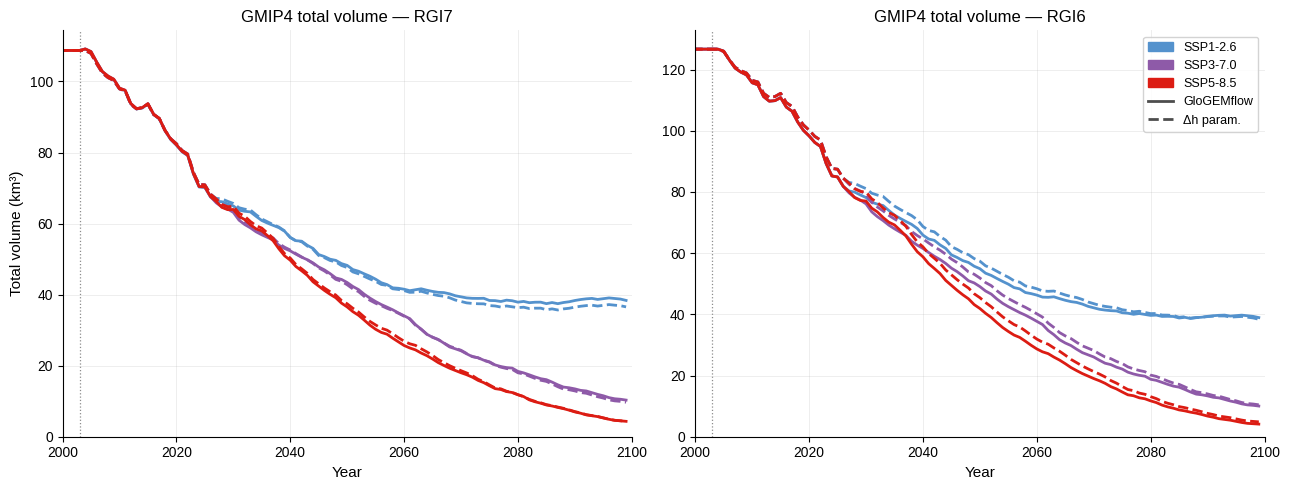

In [13]:
# ── Figure (GMIP4): Total volume — RGI7 (left) vs RGI6 (right) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (rgi_label, flow_tag, dh_tag) in zip(axes, PANELS):
    for ssp in GMIP4_SSPS:
        c = GMIP4_SSP_COLORS[ssp]
        for tag, ls in [(flow_tag, '-'), (dh_tag, '--')]:
            v = vol_gmip4[tag][ssp]
            if v is not None:
                ax.plot(years, v, color=c, ls=ls, lw=2.0)
    ax.axvline(INVENTORY_YEAR, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(f'GMIP4 total volume — {rgi_label}', fontsize=12)
    ax.grid(True, alpha=0.25, lw=0.6)

axes[0].set_ylabel('Total volume (km³)', fontsize=11)

legend_ssp = [Patch(color=GMIP4_SSP_COLORS[s], label=GMIP4_SSP_LABELS[s]) for s in GMIP4_SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=2.0, label='GloGEMflow'),
    Line2D([0], [0], color='0.3', ls='--', lw=2.0, label='Δh param.'),
]
axes[1].legend(handles=legend_ssp + legend_mdl, fontsize=9,
               loc='upper right', framealpha=0.85)

fig.tight_layout()
plt.show()

In [14]:
# ── Summary table (GMIP4) ─────────────────────────────────────────────────────
def _v_gmip4(tag, ssp, idx):
    v = vol_gmip4[tag][ssp]
    return v[idx] if v is not None else float('nan')

print('-- GMIP4 Volume 2020 (km³) --')
print(hdr);  print(sep)
for ssp in GMIP4_SSPS:
    print(f'{GMIP4_SSP_LABELS[ssp]:<12}' + ''.join(f'  {_v_gmip4(t,ssp,I_2020):>{W}.1f}' for t in TAGS))

print()
print('-- GMIP4 Volume 2099 (km³) --')
print(hdr);  print(sep)
for ssp in GMIP4_SSPS:
    print(f'{GMIP4_SSP_LABELS[ssp]:<12}' + ''.join(f'  {_v_gmip4(t,ssp,I_LAST):>{W}.1f}' for t in TAGS))

print()
print('-- GMIP4 Volume loss 2020→2099 (%) --')
print(hdr);  print(sep)
for ssp in GMIP4_SSPS:
    row = f'{GMIP4_SSP_LABELS[ssp]:<12}'
    for tag in TAGS:
        v20, v99 = _v_gmip4(tag, ssp, I_2020), _v_gmip4(tag, ssp, I_LAST)
        loss = (1 - v99 / v20) * 100 if v20 > 0 else float('nan')
        row += f'  {loss:>{W}.1f}%'
    print(row)

print('\nΔh = Δh parameterisation.  Flow = GloGEMflow.  All volumes in km³.  GMIP4 ensemble: 8 models.')

-- GMIP4 Volume 2020 (km³) --
SSP              Δh-RGI7     Δh-RGI6   Flow-RGI7   Flow-RGI6
------------------------------------------------------------
SSP1-2.6            82.5       100.2        82.1        98.3
SSP3-7.0            82.5       100.2        82.2        98.3
SSP5-8.5            82.5       100.2        82.2        98.3

-- GMIP4 Volume 2099 (km³) --
SSP              Δh-RGI7     Δh-RGI6   Flow-RGI7   Flow-RGI6
------------------------------------------------------------
SSP1-2.6            36.5        38.4        38.4        38.9
SSP3-7.0             9.7        10.4        10.3        10.0
SSP5-8.5             4.4         4.9         4.3         4.1

-- GMIP4 Volume loss 2020→2099 (%) --
SSP              Δh-RGI7     Δh-RGI6   Flow-RGI7   Flow-RGI6
------------------------------------------------------------
SSP1-2.6            55.7%        61.7%        53.2%        60.4%
SSP3-7.0            88.2%        89.6%        87.5%        89.8%
SSP5-8.5            94.7%        95.1%

## CentralEurope — RGI7 driver-glacier identification

Which individual RGI7 glaciers drive the end-of-century (2099) volume divergence between the Δh
parameterisation and GloGEMflow, and is that divergence associated with rough/unreliable input ice
thickness geometry (the Millan-type product used for RGI7, which has known bedrock-roughness issues
and at least one confirmed artifact — a ~60 m ice cliff at Morteratsch's front)?

Uses the CMIP6 ensemble (13 GCMs, larger ensemble than GMIP4's 8) for statistical power; per-glacier
(not regionally-summed) volume trajectories for both `alps_flow_rgi7` and `alps_dhdt_rgi7`, ranked by
`|flow − Δh|` at 2099, then cross-referenced against a roughness metric (RMS band-to-band ice
thickness jump ÷ mean thickness) computed from each glacier's `geometricdata/rgiv7/bands/centraleurope`
geometry file.

In [15]:
# ── Per-glacier (not regionally-summed) volume trajectories, RGI7 CMIP6 ──────
def _read_per_glacier(path, row_max=50.0):
    """Like _read_dat, but returns {glacier_id: array(160)} instead of a sum."""
    out = {}
    try:
        with open(path) as fh:
            header = fh.readline()
            ncols = len(header.split()) - 1
            if ncols <= 0:
                return out
            for line in fh:
                parts = line.split()
                if len(parts) < 2:
                    continue
                gid = parts[0]
                vals = np.zeros(ncols)
                peak = 0.0
                for j, tok in enumerate(parts[1:ncols + 1]):
                    try:
                        v = float(tok)
                    except ValueError:
                        v = 0.0
                    if np.isnan(v):
                        v = 0.0   # melted glacier -> zero, not nan
                    vals[j] = v
                    if v > peak:
                        peak = v
                if row_max is not None and peak > row_max:
                    continue
                out[gid] = vals
    except (FileNotFoundError, OSError, ValueError):
        pass
    return out


def _load_gcm_per_glacier(args):
    rundir, ssp, gcm = args
    merged = {}
    for i in range(1, N_BATCHES + 1):
        path = (f'{rundir}/{_SUB}/{gcm}/{ssp}/'
                f'centraleurope_Volume_r1_{BATCH_PREFIX}{i:02d}.dat')
        merged.update(_read_per_glacier(path))
    return merged


def load_per_glacier_mean(rundir, ssp, gcms):
    """Per-glacier GCM-ensemble mean volume trajectory."""
    args = [(rundir, ssp, gcm) for gcm in gcms]
    with ThreadPoolExecutor(max_workers=len(gcms)) as ex:
        per_gcm = list(ex.map(_load_gcm_per_glacier, args))
    all_ids = set()
    for d in per_gcm:
        all_ids |= set(d.keys())
    return {gid: np.mean([d[gid] for d in per_gcm if gid in d], axis=0) for gid in all_ids}


print('Loading per-glacier RGI7 flow/Δh volume trajectories (CMIP6, 13 GCMs, 3 SSPs)...')
flow_pergl = {ssp: load_per_glacier_mean(RUNS['flow_rgi7'], ssp, ALL_GCMS) for ssp in SSPS}
dh_pergl   = {ssp: load_per_glacier_mean(RUNS['dh_rgi7'],   ssp, ALL_GCMS) for ssp in SSPS}
for ssp in SSPS:
    print(f'{ssp}: flow {len(flow_pergl[ssp])} glaciers, dh {len(dh_pergl[ssp])} glaciers')

Loading per-glacier RGI7 flow/Δh volume trajectories (CMIP6, 13 GCMs, 3 SSPs)...


ssp126: flow 4071 glaciers, dh 4072 glaciers
ssp245: flow 4071 glaciers, dh 4072 glaciers
ssp585: flow 4071 glaciers, dh 4072 glaciers


In [16]:
# ── Rank RGI7 glaciers by |flow − Δh| volume at 2099 ─────────────────────────
ssp_rank = 'ssp585'   # strongest divergence signal; cross-SSP check follows
common_ids = set(flow_pergl[ssp_rank]) & set(dh_pergl[ssp_rank])
print(f'Glaciers present in both flow and Δh ({ssp_rank}): {len(common_ids)}')

driver_rows = []
for gid in common_ids:
    vf, vd = flow_pergl[ssp_rank][gid], dh_pergl[ssp_rank][gid]
    driver_rows.append((gid, vf[I_LAST] - vd[I_LAST], vd[I_2020], vf[I_LAST], vd[I_LAST]))
driver_rows.sort(key=lambda r: -abs(r[1]))

TOP_N = 25
top_drivers = driver_rows[:TOP_N]
top_driver_ids = [r[0] for r in top_drivers]

total_abs_diff = sum(abs(r[1]) for r in driver_rows)
top_abs_diff = sum(abs(r[1]) for r in top_drivers)
print(f'\nTop {TOP_N} RGI7 glaciers by |flow − Δh| volume at 2099 ({SSP_LABELS[ssp_rank]}):')
print(f"{'RGI_ID':<8} {'diff2099':>9} {'vol2020':>9} {'flow2099':>9} {'dh2099':>9}   sign")
for gid, diff, v20, vf99, vd99 in top_drivers:
    sign = 'flow>Δh' if diff > 0 else 'Δh>flow'
    print(f'{gid:<8} {diff:>9.3f} {v20:>9.3f} {vf99:>9.3f} {vd99:>9.3f}   {sign}')

print(f'\nTotal |flow-Δh| summed across all {len(driver_rows)} glaciers: {total_abs_diff:.2f} km³')
print(f'Top {TOP_N} alone account for {top_abs_diff:.2f} km³ '
      f'({100*top_abs_diff/total_abs_diff:.1f}% of total |divergence|)')

Glaciers present in both flow and Δh (ssp585): 4071

Top 25 RGI7 glaciers by |flow − Δh| volume at 2099 (SSP5-8.5):
RGI_ID    diff2099   vol2020  flow2099    dh2099   sign
03239        0.813     1.144     0.813     0.000   flow>Δh
00925        0.452     0.243     0.462     0.010   flow>Δh
00773        0.322     0.869     0.562     0.240   flow>Δh
01379        0.244     0.079     0.249     0.005   flow>Δh
00955        0.220     0.290     0.233     0.013   flow>Δh
00757       -0.176     2.322     0.000     0.176   Δh>flow
00912        0.168     0.027     0.169     0.001   flow>Δh
00565        0.166     0.025     0.166     0.000   flow>Δh
01760        0.160     0.002     0.160     0.000   flow>Δh
03124        0.101     0.220     0.101     0.000   flow>Δh
01545        0.092     0.211     0.110     0.017   flow>Δh
00907        0.083     0.659     0.099     0.016   flow>Δh
00188        0.080     0.059     0.083     0.003   flow>Δh
01581        0.070     1.079     0.157     0.087   flow>Δh
00

In [17]:
# ── Cross-check: is divergence associated with ice-thickness-product roughness? ──
import glob as _glob2
import os as _os2
import re as _re2
from scipy import stats as _stats

BANDS_DIR = '/itet-stor/jabeer/glogem/geometricdata/rgiv7/bands/centraleurope'

def read_band_geometry(gid):
    """Parse geometricdata/rgiv7/bands/centraleurope/<ID>.dat -> area, volume,
    and ice-covered-band thickness array (bands are in elevation order)."""
    path = f'{BANDS_DIR}/{gid}.dat'
    if not _os2.path.exists(path):
        return None
    with open(path) as fh:
        lines = fh.readlines()
    try:
        area_km2 = float(_re2.search(r'Area \(km2\):\s*([\d.]+)', lines[2]).group(1))
        vol_km3  = float(_re2.search(r'Volume \(km3\):\s*([\d.]+)', lines[3]).group(1))
    except (AttributeError, IndexError):
        return None
    thick = []
    for line in lines[5:]:
        parts = line.split()
        if len(parts) < 5:
            continue
        a, t = float(parts[3]), float(parts[4])
        if a > 0 and t > 0:
            thick.append(t)
    thick = np.array(thick)
    if len(thick) < 2:
        return None
    return dict(area_km2=area_km2, vol_km3=vol_km3, thick=thick)


def roughness_ratio(thick):
    """RMS band-to-band ice-thickness jump / mean thickness."""
    jumps = np.diff(thick)
    return np.sqrt(np.mean(jumps**2)) / np.mean(thick)


# Population roughness distribution (all RGI7 CentralEurope glaciers with geometry)
pop_rough, pop_vol = [], []
for f in _glob2.glob(f'{BANDS_DIR}/*.dat'):
    gid = _os2.path.basename(f).replace('.dat', '')
    g = read_band_geometry(gid)
    if g is not None:
        pop_rough.append(roughness_ratio(g['thick']))
        pop_vol.append(g['vol_km3'])
pop_rough = np.array(pop_rough)
pop_vol = np.array(pop_vol)
print(f'Population: {len(pop_rough)} RGI7 CentralEurope glaciers with band geometry')
print(f'Roughness ratio — median={np.median(pop_rough):.3f}  mean={np.mean(pop_rough):.3f}  '
      f'p90={np.percentile(pop_rough, 90):.3f}')

print(f'\n--- Top {TOP_N} driver glaciers: geometry + roughness percentile in full population ---')
print(f"{'RGI_ID':<8} {'area_km2':>9} {'vol_km3':>9} {'roughness':>10} {'pctile':>8}")
for gid, diff, v20, vf99, vd99 in top_drivers:
    g = read_band_geometry(gid)
    if g is None:
        print(f'{gid:<8}  (no band geometry found)')
        continue
    r = roughness_ratio(g['thick'])
    pctile = (pop_rough < r).mean() * 100
    print(f"{gid:<8} {g['area_km2']:>9.3f} {g['vol_km3']:>9.3f} {r:>10.3f} {pctile:>7.1f}%")

# Does roughness predict divergence magnitude beyond a simple glacier-size effect?
rows = []
for gid in common_ids:
    g = read_band_geometry(gid)
    if g is None:
        continue
    diff = abs(flow_pergl[ssp_rank][gid][I_LAST] - dh_pergl[ssp_rank][gid][I_LAST])
    rows.append((diff, g['vol_km3'], roughness_ratio(g['thick'])))
diffs_all = np.array([r[0] for r in rows])
vols_all  = np.array([r[1] for r in rows])
rough_all = np.array([r[2] for r in rows])

rd, rv, rr = _stats.rankdata(diffs_all), _stats.rankdata(vols_all), _stats.rankdata(rough_all)
resid_d = rd - np.polyval(np.polyfit(rv, rd, 1), rv)
resid_r = rr - np.polyval(np.polyfit(rv, rr, 1), rv)
partial_corr = np.corrcoef(resid_d, resid_r)[0, 1]

print(f'\nSpearman correlation, |flow-Δh diff| vs volume:    {_stats.spearmanr(vols_all, diffs_all).correlation:.3f}')
print(f'Spearman correlation, |flow-Δh diff| vs roughness: {_stats.spearmanr(rough_all, diffs_all).correlation:.3f}')
print(f'Partial correlation, roughness vs |diff| controlling for volume: {partial_corr:.3f}')
print('(volume unsurprisingly dominates — bigger glaciers mechanically show bigger absolute')
print(' differences — but roughness retains independent explanatory power after controlling for it.)')

Population: 4067 RGI7 CentralEurope glaciers with band geometry
Roughness ratio — median=0.104  mean=0.131  p90=0.249

--- Top 25 driver glaciers: geometry + roughness percentile in full population ---
RGI_ID    area_km2   vol_km3  roughness   pctile
03239       16.890     1.611      0.215    84.4%
00925        6.126     0.314      0.207    83.3%
00773       10.910     0.897      0.338    96.8%
01379        2.495     0.099      0.289    94.0%
00955        5.280     0.326      0.365    97.8%
00757       30.670     2.806      0.200    82.1%
00912        0.542     0.024      0.154    71.8%
00565        1.203     0.040      0.134    64.4%
01760        0.292     0.005      0.109    53.3%
03124        8.600     0.499      0.190    80.5%
01545        3.942     0.250      0.260    91.1%
00907       10.460     0.758      0.258    90.9%
00188        1.790     0.058      0.258    90.9%
01581       18.820     1.380      0.276    92.5%
00937        4.070     0.253      0.314    95.6%
00231        2


Spearman correlation, |flow-Δh diff| vs volume:    0.566
Spearman correlation, |flow-Δh diff| vs roughness: 0.376
Partial correlation, roughness vs |diff| controlling for volume: 0.218
(volume unsurprisingly dominates — bigger glaciers mechanically show bigger absolute
 differences — but roughness retains independent explanatory power after controlling for it.)


## Iceland, New Zealand, Caucasus, Svalbard & Scandinavia — GMIP4 ensemble

Same Δh-vs-GloGEMflow comparison as the CentralEurope GMIP4 section above, for five other
regions run alongside it: Iceland (568 glaciers), New Zealand (3018 glaciers), Caucasus
(2275 glaciers, largest ~3.98 km³), Svalbard (ice-cap dominated, largest single glacier
~456 km³/~2331 km²), and Scandinavia (largest ~59 km³/~72 km², just above the alpine-region
default threshold).

All were run **RGI7 only** (GMIP4's default RGI version, per project decision) — there is no
CMIP6 or driver-glacier equivalent here (yet). Note: Svalbard's Δh line only covers
ssp126/ssp534-over — ssp370/ssp585 were deliberately reused from a colleague's
already-computed, value-checked output instead of being run in-house (see the region spec
comment below), and aren't in a format this notebook reads, so those two SSPs show flow only.

GCM ensemble: the same 8 GMIP4 models as the CentralEurope GMIP4 section. SSPs: 1-2.6, 3-7.0, 5-8.5.

Iceland and New Zealand launched via `scripts/run_gmip4_iceland_newzealand.sh`; Caucasus,
Svalbard and Scandinavia via the single-region retry driver (`scripts/run_gmip4_single_region_retry.sh`)
after various infrastructure incidents along the way (IDL license exhaustion, an NFS permission
outage, and an intermittent NCDF_CREATE resource issue — see the driver scripts' own comments
for the full history). Output directories `{region}_{flow,dh}_rgi7_gmip4`.

In [18]:
# ── Iceland & New Zealand region specs (RGI7 only, GMIP4 ensemble) ──────────
# vol_row_max / area_row_max: the blow-up filter in _read_dat() treats any
# glacier whose reported value ever exceeds this as a numerical SIA blow-up
# and drops it entirely. The 50 km3 / 500 km2 defaults above are tuned for
# CentralEurope's Alpine glaciers (largest ~5 km3) -- fine for New Zealand
# too (largest ~12.5 km3), but Iceland has genuinely huge ice caps: glacier
# 00227 (Vatnajökull) alone peaks at ~870 km3 / 1560 km2 in this model, so
# the CentralEurope thresholds would silently discard it (and several other
# large Icelandic ice caps) as if they were blown-up glaciers, undercounting
# Iceland's true regional volume/area substantially. Raised well above that
# observed max but still far below what an actual SIA blow-up would produce.
ICELAND = dict(
    dirs=dict(dh=f'{_BASE}/iceland_dh_rgi7_gmip4', flow=f'{_BASE}/iceland_flow_rgi7_gmip4'),
    sub_path='monthly/Iceland/files/files_original',
    file_prefix='iceland', batch_prefix='iceland_batch', n_batches=4,
    label='Iceland', vol_row_max=5000., area_row_max=5000.,
)
NEW_ZEALAND = dict(
    dirs=dict(dh=f'{_BASE}/newzealand_dh_rgi7_gmip4', flow=f'{_BASE}/newzealand_flow_rgi7_gmip4'),
    sub_path='monthly/NewZealand/files/files_original',
    file_prefix='newzealand', batch_prefix='newzealand_batch', n_batches=16,
    label='New Zealand', vol_row_max=50., area_row_max=500.,
)
CAUCASUS = dict(
    dirs=dict(dh=f'{_BASE}/caucasus_dh_rgi7_gmip4', flow=f'{_BASE}/caucasus_flow_rgi7_gmip4'),
    sub_path='monthly/Caucasus/files/files_original',
    file_prefix='caucasus', batch_prefix='caucasus_batch', n_batches=12,
    label='Caucasus', vol_row_max=50., area_row_max=500.,
)

# Svalbard: another ice-cap region like Iceland -- largest single-glacier
# volume/area in the actual output (checked directly, both dh and flow,
# 2026-08-18) is ~456 km3 / ~2331 km2, so thresholds need the same
# Iceland-style headroom, not the CentralEurope/Caucasus/NZ alpine-glacier
# defaults.
#
# dh (Δh parameterisation) here only has OUR OWN data for ssp126/ssp534-over
# -- ssp370/ssp585 were deliberately never run in-house and are instead
# reused from lvantrich's already-computed, value-checked output (3.46% max
# deviation from our own independent Caucasus run, see combine_gmip4_output.py
# REUSE_SOURCES), which lives in a different file format/location this
# notebook's loader doesn't read. load_mean() will correctly report
# '[missing all]' for dh/ssp370 and dh/ssp585 below -- that's the expected,
# deliberate result of the reuse strategy, not a bug -- so Svalbard's dh
# line will only appear for ssp126/ssp534-over in the plots that follow.
SVALBARD = dict(
    dirs=dict(dh=f'{_BASE}/svalbard_dh_rgi7_gmip4', flow=f'{_BASE}/svalbard_flow_rgi7_gmip4'),
    sub_path='monthly/Svalbard/files/files_original',
    file_prefix='svalbard', batch_prefix='svalbard_batch', n_batches=8,
    label='Svalbard', vol_row_max=2000., area_row_max=5000.,
)
# Scandinavia: alpine-scale glaciers like Caucasus/NZ, but its largest
# (~59 km3 / ~72 km2, checked directly) is just *above* the CentralEurope/
# Caucasus/NZ default (50 km3) -- that default would silently clip
# Scandinavia's single largest glacier, so it needs its own, slightly
# higher threshold rather than reusing CAUCASUS's.
SCANDINAVIA = dict(
    dirs=dict(dh=f'{_BASE}/scandinavia_dh_rgi7_gmip4', flow=f'{_BASE}/scandinavia_flow_rgi7_gmip4'),
    sub_path='monthly/Scandinavia/files/files_original',
    file_prefix='scandinavia', batch_prefix='scandinavia_batch', n_batches=16,
    label='Scandinavia', vol_row_max=200., area_row_max=500.,
)

In [19]:
# ── Load GMIP4 volume + area for Iceland, New Zealand, Caucasus, Svalbard &
#    Scandinavia (same machinery as the CentralEurope GMIP4 section,
#    generalised via load_mean's region kwargs) ─────────────────────────────
def load_region_gmip4(region):
    vol, area = {}, {}
    for method, rundir in region['dirs'].items():
        vol[method], area[method] = {}, {}
        for ssp in GMIP4_SSPS:
            common = dict(gcms=GMIP4_GCMS, sub_path=region['sub_path'],
                          file_prefix=region['file_prefix'],
                          batch_prefix=region['batch_prefix'],
                          n_batches=region['n_batches'])
            vol[method][ssp]  = load_mean(rundir, 'Volume', ssp, row_max=region['vol_row_max'],  **common)
            area[method][ssp] = load_mean(rundir, 'Area',   ssp, row_max=region['area_row_max'], **common)
    return vol, area

vol_iceland, area_iceland   = load_region_gmip4(ICELAND)
vol_nz, area_nz             = load_region_gmip4(NEW_ZEALAND)
vol_caucasus, area_caucasus = load_region_gmip4(CAUCASUS)
vol_svalbard, area_svalbard = load_region_gmip4(SVALBARD)
vol_scandinavia, area_scandinavia = load_region_gmip4(SCANDINAVIA)

# Sanity check
for label, vol_r in [('Iceland', vol_iceland), ('New Zealand', vol_nz), ('Caucasus', vol_caucasus),
                      ('Svalbard', vol_svalbard), ('Scandinavia', vol_scandinavia)]:
    for method in ('dh', 'flow'):
        for ssp in GMIP4_SSPS:
            v = vol_r[method][ssp]
            if v is not None:
                print(f'{label:<12} {method:<5} {GMIP4_SSP_LABELS[ssp]}  '
                      f'vol_2020={v[I_2020]:.3f} km³   vol_2099={v[I_LAST]:.3f} km³')

[missing all] ACCESS-ESM1-5/ssp370/Volume
[missing all] BCC-CSM2-MR/ssp370/Volume
[missing all] CESM2-WACCM/ssp370/Volume
[missing all] IPSL-CM6A-LR/ssp370/Volume
[missing all] MIROC6/ssp370/Volume
[missing all] MPI-ESM1-2-HR/ssp370/Volume
[missing all] MRI-ESM2-0/ssp370/Volume
[missing all] NorESM2-MM/ssp370/Volume
[missing all] ACCESS-ESM1-5/ssp370/Area
[missing all] BCC-CSM2-MR/ssp370/Area
[missing all] CESM2-WACCM/ssp370/Area
[missing all] IPSL-CM6A-LR/ssp370/Area
[missing all] MIROC6/ssp370/Area
[missing all] MPI-ESM1-2-HR/ssp370/Area
[missing all] MRI-ESM2-0/ssp370/Area
[missing all] NorESM2-MM/ssp370/Area
[missing all] ACCESS-ESM1-5/ssp585/Volume
[missing all] BCC-CSM2-MR/ssp585/Volume
[missing all] CESM2-WACCM/ssp585/Volume
[missing all] IPSL-CM6A-LR/ssp585/Volume
[missing all] MIROC6/ssp585/Volume
[missing all] MPI-ESM1-2-HR/ssp585/Volume
[missing all] MRI-ESM2-0/ssp585/Volume
[missing all] NorESM2-MM/ssp585/Volume
[missing all] ACCESS-ESM1-5/ssp585/Area
[missing all] BCC-CSM2

[partial 12/16] NorESM2-MM/ssp585/Volume


[partial 12/16] NorESM2-MM/ssp585/Area


Iceland      dh    SSP1-2.6  vol_2020=4444.420 km³   vol_2099=3698.355 km³
Iceland      dh    SSP3-7.0  vol_2020=4444.420 km³   vol_2099=3054.172 km³
Iceland      dh    SSP5-8.5  vol_2020=4444.420 km³   vol_2099=2716.841 km³
Iceland      flow  SSP1-2.6  vol_2020=4440.645 km³   vol_2099=3468.061 km³
Iceland      flow  SSP3-7.0  vol_2020=4440.645 km³   vol_2099=2708.547 km³
Iceland      flow  SSP5-8.5  vol_2020=4440.645 km³   vol_2099=2337.678 km³
New Zealand  dh    SSP1-2.6  vol_2020=59.556 km³   vol_2099=34.933 km³
New Zealand  dh    SSP3-7.0  vol_2020=59.556 km³   vol_2099=17.507 km³
New Zealand  dh    SSP5-8.5  vol_2020=59.556 km³   vol_2099=14.928 km³
New Zealand  flow  SSP1-2.6  vol_2020=57.886 km³   vol_2099=32.991 km³
New Zealand  flow  SSP3-7.0  vol_2020=57.899 km³   vol_2099=19.203 km³
New Zealand  flow  SSP5-8.5  vol_2020=57.899 km³   vol_2099=16.759 km³
Caucasus     dh    SSP1-2.6  vol_2020=62.748 km³   vol_2099=31.247 km³
Caucasus     dh    SSP3-7.0  vol_2020=62.748 km³   vo

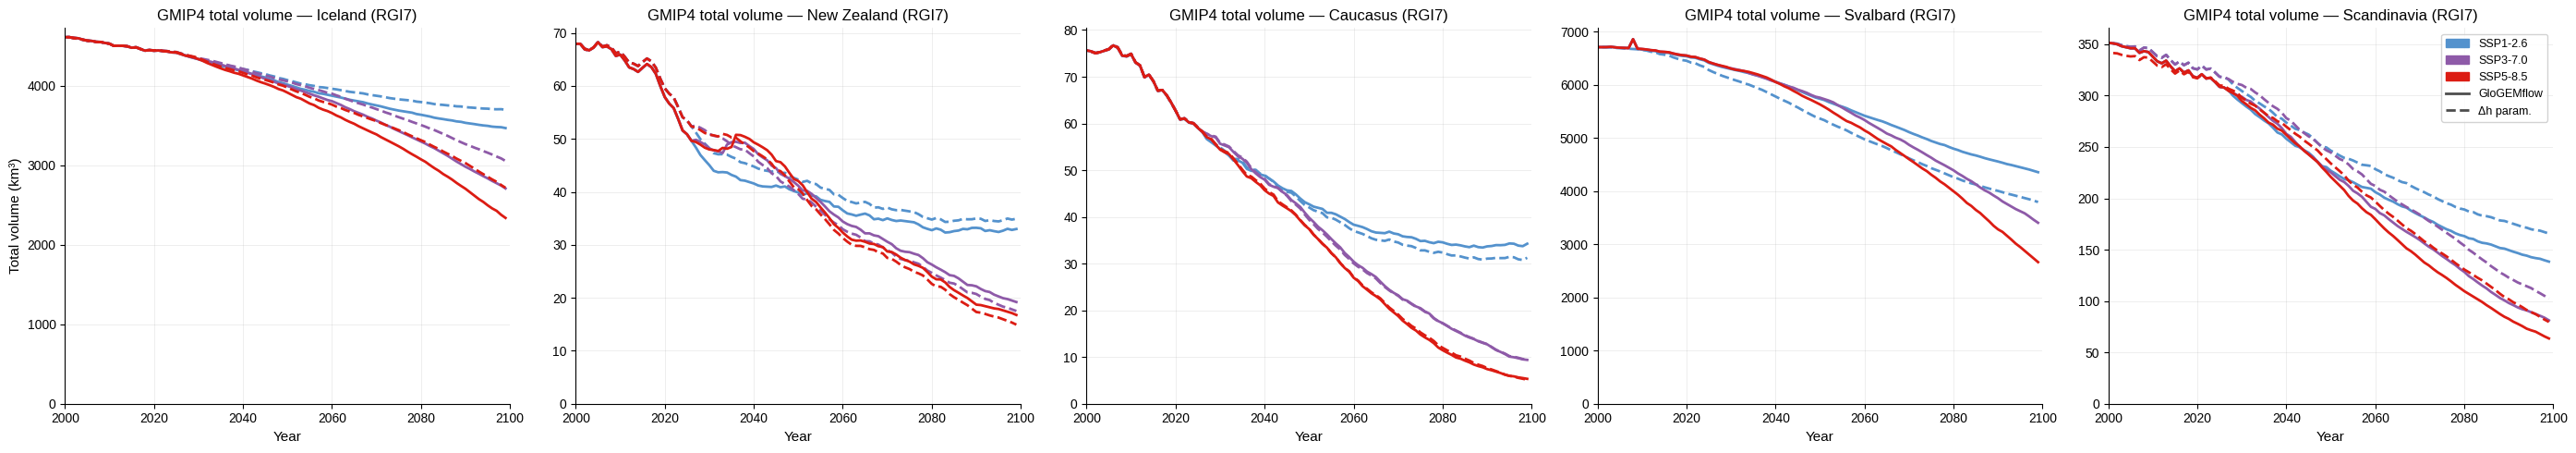

In [20]:
# ── Figure (GMIP4): Total volume — Iceland / New Zealand / Caucasus / Svalbard / Scandinavia ──
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

REGIONS_INZ = [('Iceland', vol_iceland), ('New Zealand', vol_nz), ('Caucasus', vol_caucasus),
               ('Svalbard', vol_svalbard), ('Scandinavia', vol_scandinavia)]
for ax, (region_label, vol_region) in zip(axes, REGIONS_INZ):
    for ssp in GMIP4_SSPS:
        c = GMIP4_SSP_COLORS[ssp]
        for method, ls in [('flow', '-'), ('dh', '--')]:
            v = vol_region[method][ssp]
            if v is not None:
                ax.plot(years, v, color=c, ls=ls, lw=2.0)
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(f'GMIP4 total volume — {region_label} (RGI7)', fontsize=12)
    ax.grid(True, alpha=0.25, lw=0.6)

axes[0].set_ylabel('Total volume (km³)', fontsize=11)

legend_ssp = [Patch(color=GMIP4_SSP_COLORS[s], label=GMIP4_SSP_LABELS[s]) for s in GMIP4_SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=2.0, label='GloGEMflow'),
    Line2D([0], [0], color='0.3', ls='--', lw=2.0, label='Δh param.'),
]
axes[4].legend(handles=legend_ssp + legend_mdl, fontsize=9,
               loc='upper right', framealpha=0.85)

fig.tight_layout()
plt.show()

In [21]:
# ── Summary table (Iceland, New Zealand, Caucasus, Svalbard & Scandinavia, GMIP4) ─
REGION_VOLS = [('Iceland', vol_iceland), ('New Zealand', vol_nz), ('Caucasus', vol_caucasus),
               ('Svalbard', vol_svalbard), ('Scandinavia', vol_scandinavia)]
COLS2 = [f'{lbl}-{m}' for lbl, _ in REGION_VOLS for m in ('Δh', 'Flow')]
W2 = 12

hdr2 = f"{'SSP':<12}" + "".join(f"  {c:>{W2}}" for c in COLS2)
sep2 = '-' * len(hdr2)

def _v_region(vol_region, method, ssp, idx):
    v = vol_region[method][ssp]
    return v[idx] if v is not None else float('nan')

print('-- GMIP4 Volume 2020 (km³) --')
print(hdr2); print(sep2)
for ssp in GMIP4_SSPS:
    row = f'{GMIP4_SSP_LABELS[ssp]:<12}'
    for _, vol_region in REGION_VOLS:
        for method in ('dh', 'flow'):
            row += f'  {_v_region(vol_region, method, ssp, I_2020):>{W2}.3f}'
    print(row)

print()
print('-- GMIP4 Volume 2099 (km³) --')
print(hdr2); print(sep2)
for ssp in GMIP4_SSPS:
    row = f'{GMIP4_SSP_LABELS[ssp]:<12}'
    for _, vol_region in REGION_VOLS:
        for method in ('dh', 'flow'):
            row += f'  {_v_region(vol_region, method, ssp, I_LAST):>{W2}.3f}'
    print(row)

print()
print('-- GMIP4 Volume loss 2020→2099 (%) --')
print(hdr2); print(sep2)
for ssp in GMIP4_SSPS:
    row = f'{GMIP4_SSP_LABELS[ssp]:<12}'
    for _, vol_region in REGION_VOLS:
        for method in ('dh', 'flow'):
            v20 = _v_region(vol_region, method, ssp, I_2020)
            v99 = _v_region(vol_region, method, ssp, I_LAST)
            loss = (1 - v99 / v20) * 100 if v20 and v20 > 0 else float('nan')
            row += f'  {loss:>{W2}.1f}%'
    print(row)

print('\nΔh = Δh parameterisation.  Flow = GloGEMflow.  RGI7 only.  GMIP4 ensemble: 8 models.')
print('Svalbard Δh: ssp126/ssp534-over only (ours) -- ssp370/ssp585 reused from lvantrich, not')
print('in this notebook\'s file format, so those two cells will show as NaN here by design.')

-- GMIP4 Volume 2020 (km³) --
SSP             Iceland-Δh  Iceland-Flow  New Zealand-Δh  New Zealand-Flow   Caucasus-Δh  Caucasus-Flow   Svalbard-Δh  Svalbard-Flow  Scandinavia-Δh  Scandinavia-Flow
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
SSP1-2.6          4444.420      4440.645        59.556        57.886        62.748        62.693      6456.695      6540.587       325.493       317.248
SSP3-7.0          4444.420      4440.645        59.556        57.899        62.748        62.743           nan      6554.586       325.493       317.348
SSP5-8.5          4444.420      4440.645        59.556        57.899        62.748        62.743           nan      6554.586       316.804       317.348

-- GMIP4 Volume 2099 (km³) --
SSP             Iceland-Δh  Iceland-Flow  New Zealand-Δh  New Zealand-Flow   Caucasus-Δh  Caucasus-Flow   Svalbard-Δh  Svalbard-Flow  Scandinavia-

## GMIP4 overshoot scenario (SSP5-3.4-overshoot) — CentralEurope, Iceland, New Zealand & Caucasus

Only 4 of the 8 GMIP4 GCMs submitted the `ssp534-over` CMIP6 experiment. **MIROC6 is excluded here**: its run stops at exactly 2100 (`procedures/initialise/check_tran.pro`), i.e. right where the overshoot scenario's defining feature — the post-peak decline — begins, so it never shows any overshoot behaviour and isn't a meaningful ensemble member for *any* year of this analysis. The remaining 3 (CESM2-WACCM, IPSL-CM6A-LR, MRI-ESM2-0) all run through 2299/2300. RGI7 only, matching the rest of the GMIP4 submission — the RGI6 vs RGI7 cross-check further up is a separate, CentralEurope-specific comparison, not part of this section.

In [22]:
# ── Overshoot (ssp534-over) GCM roster + extended time axis ──────────────────
# 4 of the 8 GMIP4 GCMs submitted ssp534-over. MIROC6 is excluded from this
# ensemble: its run stops at exactly 2100 (procedures/initialise/check_tran.pro)
# -- precisely where the overshoot scenario's defining feature (the post-peak
# decline) begins -- so it never actually exhibits overshoot behaviour and
# isn't a meaningful ensemble member for any year, not just the post-2100 ones.
# The remaining 3 all extend to 2299/2300 (confirmed on disk: CESM2-WACCM 360,
# IPSL-CM6A-LR 361, MRI-ESM2-0 361 year-columns) -- still 1 year ragged between
# CESM2-WACCM and the other two, hence load_mean's NaN-pad + nanmean below.
OVERSHOOT_GCMS  = ['CESM2-WACCM', 'IPSL-CM6A-LR', 'MRI-ESM2-0']
OVERSHOOT_SSP   = 'ssp534-over'
OVERSHOOT_LABEL = 'SSP5-3.4-overshoot'
OVERSHOOT_COLOR = '#00A896'

OVERSHOOT_N_YEARS = 361                                    # 1940-2300 inclusive
overshoot_years   = np.arange(TRAN0, TRAN0 + OVERSHOOT_N_YEARS)
I_2100 = 2100 - TRAN0
I_2300 = OVERSHOOT_N_YEARS - 1


In [23]:
# ── Load overshoot volume + area — CentralEurope, Iceland, New Zealand, Caucasus,
#    Svalbard & Scandinavia (RGI7 only, matching the rest of the GMIP4 submission) ──
def load_overshoot(dirs, vol_row_max=50., area_row_max=500., **loader_kwargs):
    """ssp534-over volume+area for one region's {'flow'/'dh': rundir} dict."""
    common = dict(gcms=OVERSHOOT_GCMS, n_years=OVERSHOOT_N_YEARS, **loader_kwargs)
    vol  = {m: load_mean(d, 'Volume', OVERSHOOT_SSP, row_max=vol_row_max,  **common) for m, d in dirs.items()}
    area = {m: load_mean(d, 'Area',   OVERSHOOT_SSP, row_max=area_row_max, **common) for m, d in dirs.items()}
    return vol, area

def load_overshoot_region(region):
    return load_overshoot(region['dirs'], vol_row_max=region['vol_row_max'], area_row_max=region['area_row_max'],
                           sub_path=region['sub_path'], file_prefix=region['file_prefix'],
                           batch_prefix=region['batch_prefix'], n_batches=region['n_batches'])

RUNS_GMIP4_RGI7 = {'flow': RUNS_GMIP4['flow_rgi7'], 'dh': RUNS_GMIP4['dh_rgi7']}

vol_os_ce, area_os_ce   = load_overshoot(RUNS_GMIP4_RGI7)
vol_os_ice, area_os_ice = load_overshoot_region(ICELAND)
vol_os_nz, area_os_nz   = load_overshoot_region(NEW_ZEALAND)
vol_os_cau, area_os_cau = load_overshoot_region(CAUCASUS)
vol_os_sva, area_os_sva = load_overshoot_region(SVALBARD)
vol_os_sca, area_os_sca = load_overshoot_region(SCANDINAVIA)

OS_REGIONS = [('CentralEurope', vol_os_ce), ('Iceland', vol_os_ice),
              ('New Zealand', vol_os_nz), ('Caucasus', vol_os_cau),
              ('Svalbard', vol_os_sva), ('Scandinavia', vol_os_sca)]

# Sanity check
for label, vol_r in OS_REGIONS:
    for tag in ('flow', 'dh'):
        v = vol_r[tag]
        if v is not None:
            print(f'{label:<14} {tag:<5} vol_2020={v[I_2020]:.1f}  vol_2100={v[I_2100]:.1f}  vol_2300={v[I_2300]:.1f} km³')
        else:
            print(f'{label:<14} {tag:<5} [missing]')

CentralEurope  flow  vol_2020=82.2  vol_2100=20.4  vol_2300=87.7 km³
CentralEurope  dh    vol_2020=82.5  vol_2100=18.0  vol_2300=134.8 km³
Iceland        flow  vol_2020=4440.6  vol_2100=3067.9  vol_2300=4036.5 km³
Iceland        dh    vol_2020=4444.4  vol_2100=3377.3  vol_2300=5006.0 km³
New Zealand    flow  vol_2020=57.9  vol_2100=21.4  vol_2300=38.7 km³
New Zealand    dh    vol_2020=59.6  vol_2100=23.4  vol_2300=53.7 km³
Caucasus       flow  vol_2020=62.7  vol_2100=21.2  vol_2300=51.9 km³
Caucasus       dh    vol_2020=62.7  vol_2100=19.0  vol_2300=74.9 km³
Svalbard       flow  vol_2020=6554.6  vol_2100=3656.6  vol_2300=2638.1 km³
Svalbard       dh    vol_2020=6456.7  vol_2100=3148.0  vol_2300=2166.3 km³
Scandinavia    flow  vol_2020=317.3  vol_2100=104.7  vol_2300=312.6 km³
Scandinavia    dh    vol_2020=325.5  vol_2100=130.1  vol_2300=461.4 km³


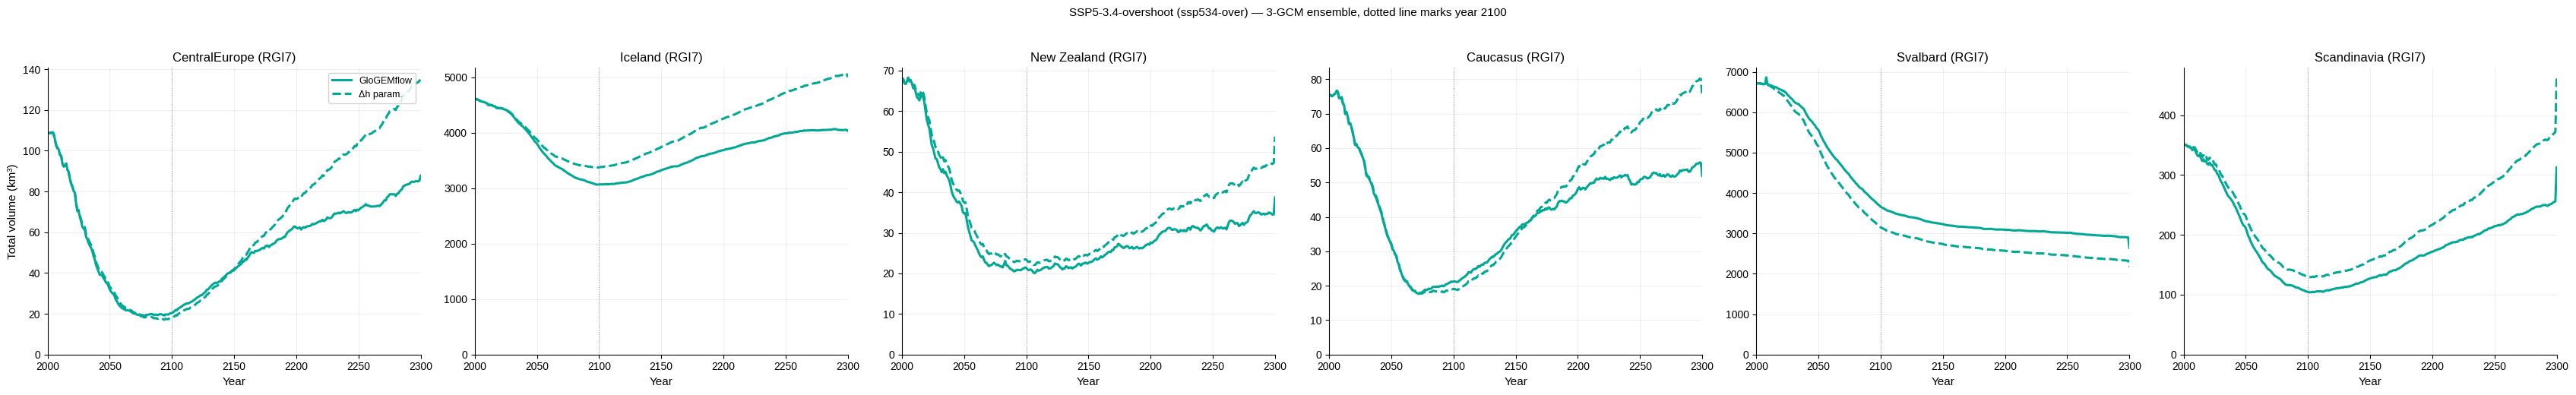

In [24]:
# ── Figure (overshoot): Total volume 2000-2300 — CentralEurope / Iceland / New Zealand / Caucasus / Svalbard / Scandinavia ──
fig, axes = plt.subplots(1, 6, figsize=(34, 5))

for ax, (region_label, vol_region) in zip(axes, OS_REGIONS):
    for tag, ls in [('flow', '-'), ('dh', '--')]:
        v = vol_region[tag]
        if v is not None:
            ax.plot(overshoot_years, v, color=OVERSHOOT_COLOR, ls=ls, lw=2.2)
    ax.axvline(2100, color='0.6', lw=0.8, ls=':', zorder=0)
    ax.set_xlim(2000, 2300)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(f'{region_label} (RGI7)', fontsize=12)
    ax.grid(True, alpha=0.25, lw=0.6)

axes[0].set_ylabel('Total volume (km³)', fontsize=11)
fig.suptitle(f'{OVERSHOOT_LABEL} ({OVERSHOOT_SSP}) — {len(OVERSHOOT_GCMS)}-GCM ensemble, dotted line marks year 2100',
             fontsize=11, y=1.03)

legend_mdl = [
    Line2D([0], [0], color=OVERSHOOT_COLOR, ls='-',  lw=2.2, label='GloGEMflow'),
    Line2D([0], [0], color=OVERSHOOT_COLOR, ls='--', lw=2.2, label='Δh param.'),
]
axes[0].legend(handles=legend_mdl, fontsize=9, loc='upper right', framealpha=0.85)

fig.tight_layout()
plt.show()

In [25]:
# ── Summary table (overshoot) ────────────────────────────────────────────────
W3 = 12
cols3 = [f'{lbl}-{m}' for lbl, _ in OS_REGIONS for m in ('Flow', 'Δh')]
hdr3 = f"{'Year':<8}" + ''.join(f'  {c:>{W3}}' for c in cols3)

def _os_val(v, idx):
    if v is None or idx >= len(v) or np.isnan(v[idx]):
        return float('nan')
    return v[idx]

print('-- Volume (km³) --')
print(hdr3); print('-' * len(hdr3))
for yr, idx in [(2020, I_2020), (2100, I_2100), (2300, I_2300)]:
    row = f'{yr:<8}'
    for _, vol_region in OS_REGIONS:
        row += f'  {_os_val(vol_region["flow"], idx):>{W3}.1f}  {_os_val(vol_region["dh"], idx):>{W3}.1f}'
    print(row)

print()
print('-- Volume loss from 2020 (%) --')
for label_yr, idx in [('2020→2100', I_2100), ('2020→2300', I_2300)]:
    row = f'{label_yr:<8}'
    for _, vol_region in OS_REGIONS:
        for tag in ('flow', 'dh'):
            v = vol_region[tag]
            v20, vN = _os_val(v, I_2020), _os_val(v, idx)
            loss = (1 - vN / v20) * 100 if v20 and not np.isnan(v20) and not np.isnan(vN) else float('nan')
            row += f'  {loss:>{W3}.1f}%'
    print(row)

print()
print('-- Volume trough after peak warming (GloGEMflow only) --')
for label, vol_region in OS_REGIONS:
    flow_v = vol_region['flow']
    if flow_v is not None and not np.all(np.isnan(flow_v)):
        i_min = int(np.nanargmin(flow_v))
        v300 = _os_val(flow_v, I_2300)
        note = 'partial recovery by 2300' if (not np.isnan(v300) and v300 > flow_v[i_min]) else 'still declining / no recovery by 2300'
        print(f'{label:<22} min volume {flow_v[i_min]:>8.1f} km³ at year {overshoot_years[i_min]}   ({note})')

print('\nΔh = Δh parameterisation.  Flow = GloGEMflow.  RGI7 only.  '
      f'{OVERSHOOT_LABEL} ensemble: {len(OVERSHOOT_GCMS)} models ({", ".join(OVERSHOOT_GCMS)}) -- '
      'MIROC6 excluded (its ssp534-over run stops at 2100, before the overshoot period).')


-- Volume (km³) --
Year      CentralEurope-Flow  CentralEurope-Δh  Iceland-Flow    Iceland-Δh  New Zealand-Flow  New Zealand-Δh  Caucasus-Flow   Caucasus-Δh  Svalbard-Flow   Svalbard-Δh  Scandinavia-Flow  Scandinavia-Δh
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
2020              82.2          82.5        4440.6        4444.4          57.9          59.6          62.7          62.7        6554.6        6456.7         317.3         325.5
2100              20.4          18.0        3067.9        3377.3          21.4          23.4          21.2          19.0        3656.6        3148.0         104.7         130.1
2300              87.7         134.8        4036.5        5006.0          38.7          53.7          51.9          74.9        2638.1        2166.3         312.6         461.4

-- Volume loss from 2020 (%) --
2020→2100      